In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None) #To see all the columns for a better EDA

In [2]:
# global style for everything

sns.set_theme(style='darkgrid', palette='muted') # can change later 
plt.rcParams.update({ 
    "figure.dpi" : 150,
    "axes.titlesize" : 13,
    "axes.labelsize" : 12,
    "axes.titleweight" : "bold",
})

games =  pd.read_csv('../data/processed/games_clean.csv') # read the cleaned dataset
print(games.shape)
games.info()

(122610, 34)
<class 'pandas.DataFrame'>
RangeIndex: 122610 entries, 0 to 122609
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   appid                       122610 non-null  int64  
 1   name                        122610 non-null  str    
 2   release_date                122610 non-null  str    
 3   peak_ccu                    122610 non-null  int64  
 4   required_age                122610 non-null  int64  
 5   price                       122610 non-null  float64
 6   discountdlc_count           122610 non-null  int64  
 7   supported_languages         114161 non-null  str    
 8   windows                     122610 non-null  str    
 9   mac                         122610 non-null  bool   
 10  linux                       122610 non-null  bool   
 11  metacritic_score            122610 non-null  bool   
 12  positive                    122610 non-null  int64  
 13  negative    

In [3]:
games['total_reviews'] = games['positive'] + games['negative'] # get total reviews
games['positive_rate'] = np.where( # get the positive rate of games
    games['total_reviews'] > 0,    # where it has at least 1 reivew
    games['positive'] / games['total_reviews'], 
    np.nan
)

games_reviewed = games[games['total_reviews'] >= 10].copy()
print(f"games with >= 10 reviews: {len(games_reviewed):,} / {len(games):,}") # weird CHECK LATER

games with >= 10 reviews: 51,736 / 122,610


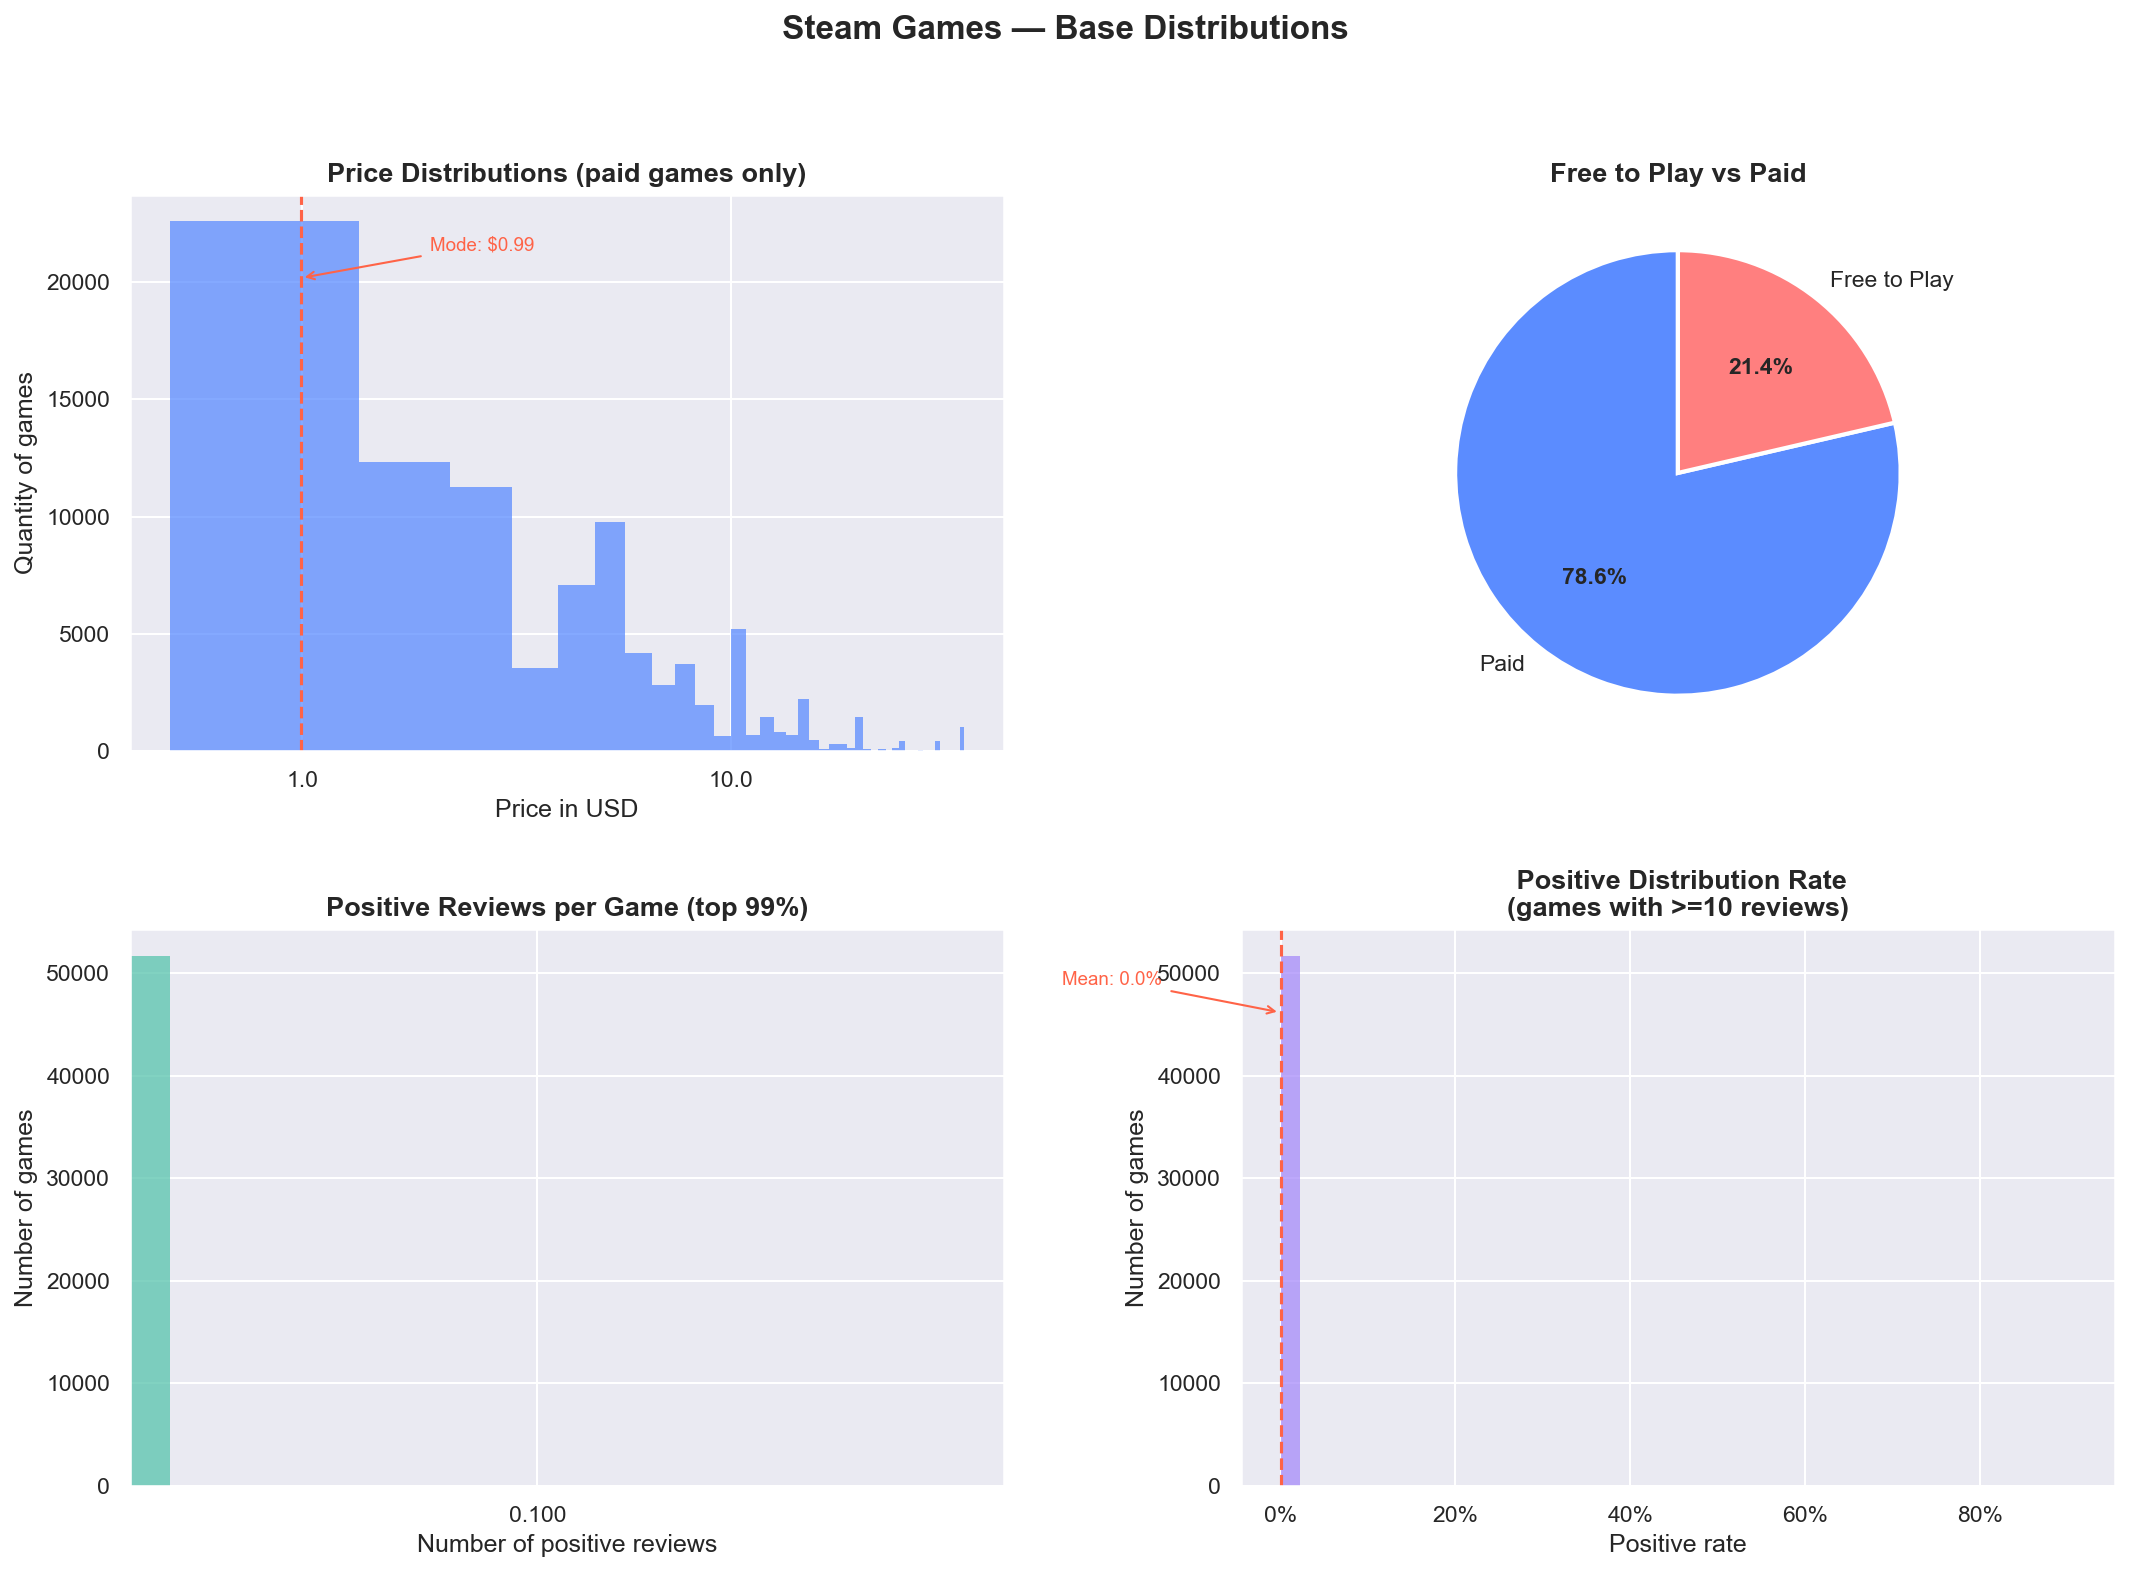

In [4]:
#Distribution base graphs

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    "Steam Games — Base Distributions",
    fontsize=16,
    fontweight="bold"
)

# =============================================================================
# PLOT 1 — Price Distributions 
# =============================================================================

ax1 = axes[0, 0]

# Only paid games
paid = games.loc[games['price'] > 0, 'price']

# Remove extreme outliers (top 1%)
paid = paid.clip(upper=paid.quantile(0.99))

# Histogram
sns.histplot(
    paid,
    bins=40,
    ax=ax1,
    color="#5B8CFF",
    edgecolor="none"
)

# Log scale
ax1.set_xscale("log")

# IMPORTANT:
# Show real values instead of log/pow
ax1.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())

# Labels
ax1.set_title("Price Distributions (paid games only)")
ax1.set_xlabel("Price in USD")
ax1.set_ylabel("Quantity of games")

# Mode
mode_price = paid.mode()[0]

ax1.axvline(
    mode_price,
    color="tomato",
    linestyle="--",
    linewidth=1.5
)

ax1.annotate(
    f"Mode: ${mode_price:.2f}",
    xy=(mode_price, ax1.get_ylim()[1] * 0.85),
    xytext=(mode_price * 2, ax1.get_ylim()[1] * 0.9),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# =============================================================================
# PLOT 2 — Free to Play vs Paid
# =============================================================================

ax2 = axes[0, 1]

f2p_counts = (
    np.where(games['price'] == 0, 'Free to Play', 'Paid')
)

f2p_counts = pd.Series(f2p_counts).value_counts()

colors = ["#5B8CFF", "#FF7F7F"]

wedges, texts, autotexts = ax2.pie(
    f2p_counts,
    labels=f2p_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight("bold")

ax2.set_title("Free to Play vs Paid")

# =============================================================================
# PLOT 3 — Positive reviews 
# =============================================================================

ax3 = axes[1, 0]

# Filter games with at least 1 positive review 
positive_reviews = games_reviewed['positive']

# Clip to remove extreme outliers
positive_reviews = positive_reviews.clip(
    upper=positive_reviews.quantile(0.99)
)

sns.histplot(
    positive_reviews,
    bins=40,
    ax=ax3,
    color="#57C4AD",
    edgecolor="none"
)

# Log scale
ax3.set_xscale("log")

# Show nums instead of log/pow 
ax3.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax3.xaxis.set_minor_formatter(mticker.NullFormatter())

ax3.set_title("Positive Reviews per Game (top 99%)")
ax3.set_xlabel("Number of positive reviews")
ax3.set_ylabel("Number of games")

# Median
median_pos = positive_reviews.median()

ax3.axvline(
    median_pos,
    color="tomato",
    linestyle="--",
    linewidth=1.5
)

ax3.annotate(
    f"Mediana: {int(median_pos):,}",
    xy=(median_pos, ax3.get_ylim()[1] * 0.7),
    xytext=(median_pos * 2, ax3.get_ylim()[1] * 0.8),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# =============================================================================
# PLOT 4 — Positive rate
# =============================================================================

ax4 = axes[1, 1]

# IMPORTANT:
# Filter valid values
positive_rate = games_reviewed['positive_rate']

positive_rate = positive_rate[
    (positive_rate >= 0) &
    (positive_rate <= 1)
]

sns.histplot(
    positive_rate,
    bins=40,
    ax=ax4,
    color="#A78BFA",
    edgecolor="none"
)

ax4.set_title(" Positive Distribution Rate\n(games with >=10 reviews)")
ax4.set_xlabel("Positive rate")
ax4.set_ylabel("Number of games")

# Percentage(%) format in X 
ax4.xaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1)
)

# Mean
mean_rate = positive_rate.mean()

ax4.axvline(
    mean_rate,
    color="tomato",
    linestyle="--",
    linewidth=1.5
)

ax4.annotate(
    f"Mean: {mean_rate:.1%}",
    xy=(mean_rate, ax4.get_ylim()[1] * 0.85),
    xytext=(mean_rate - 0.25, ax4.get_ylim()[1] * 0.9),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# =============================================================================
# FINAL AJUSTSMENTS
# =============================================================================

plt.tight_layout(pad=3)

plt.savefig(
    '../images/01_base_distributions.png',
    bbox_inches='tight',
    dpi=150
)

plt.show() #STILL WEIRD, THINK ORIGINAL FILE WAS CORRUPTED NEED TO CHECK ONCE BACK

C:\Users\death\AppData\Local\Temp\ipykernel_21920\3232962591.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
C:\Users\death\AppData\Local\Temp\ipykernel_21920\3232962591.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
C:\Users\death\AppData\Local\Temp\ipykernel_21920\3232962591.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=8)


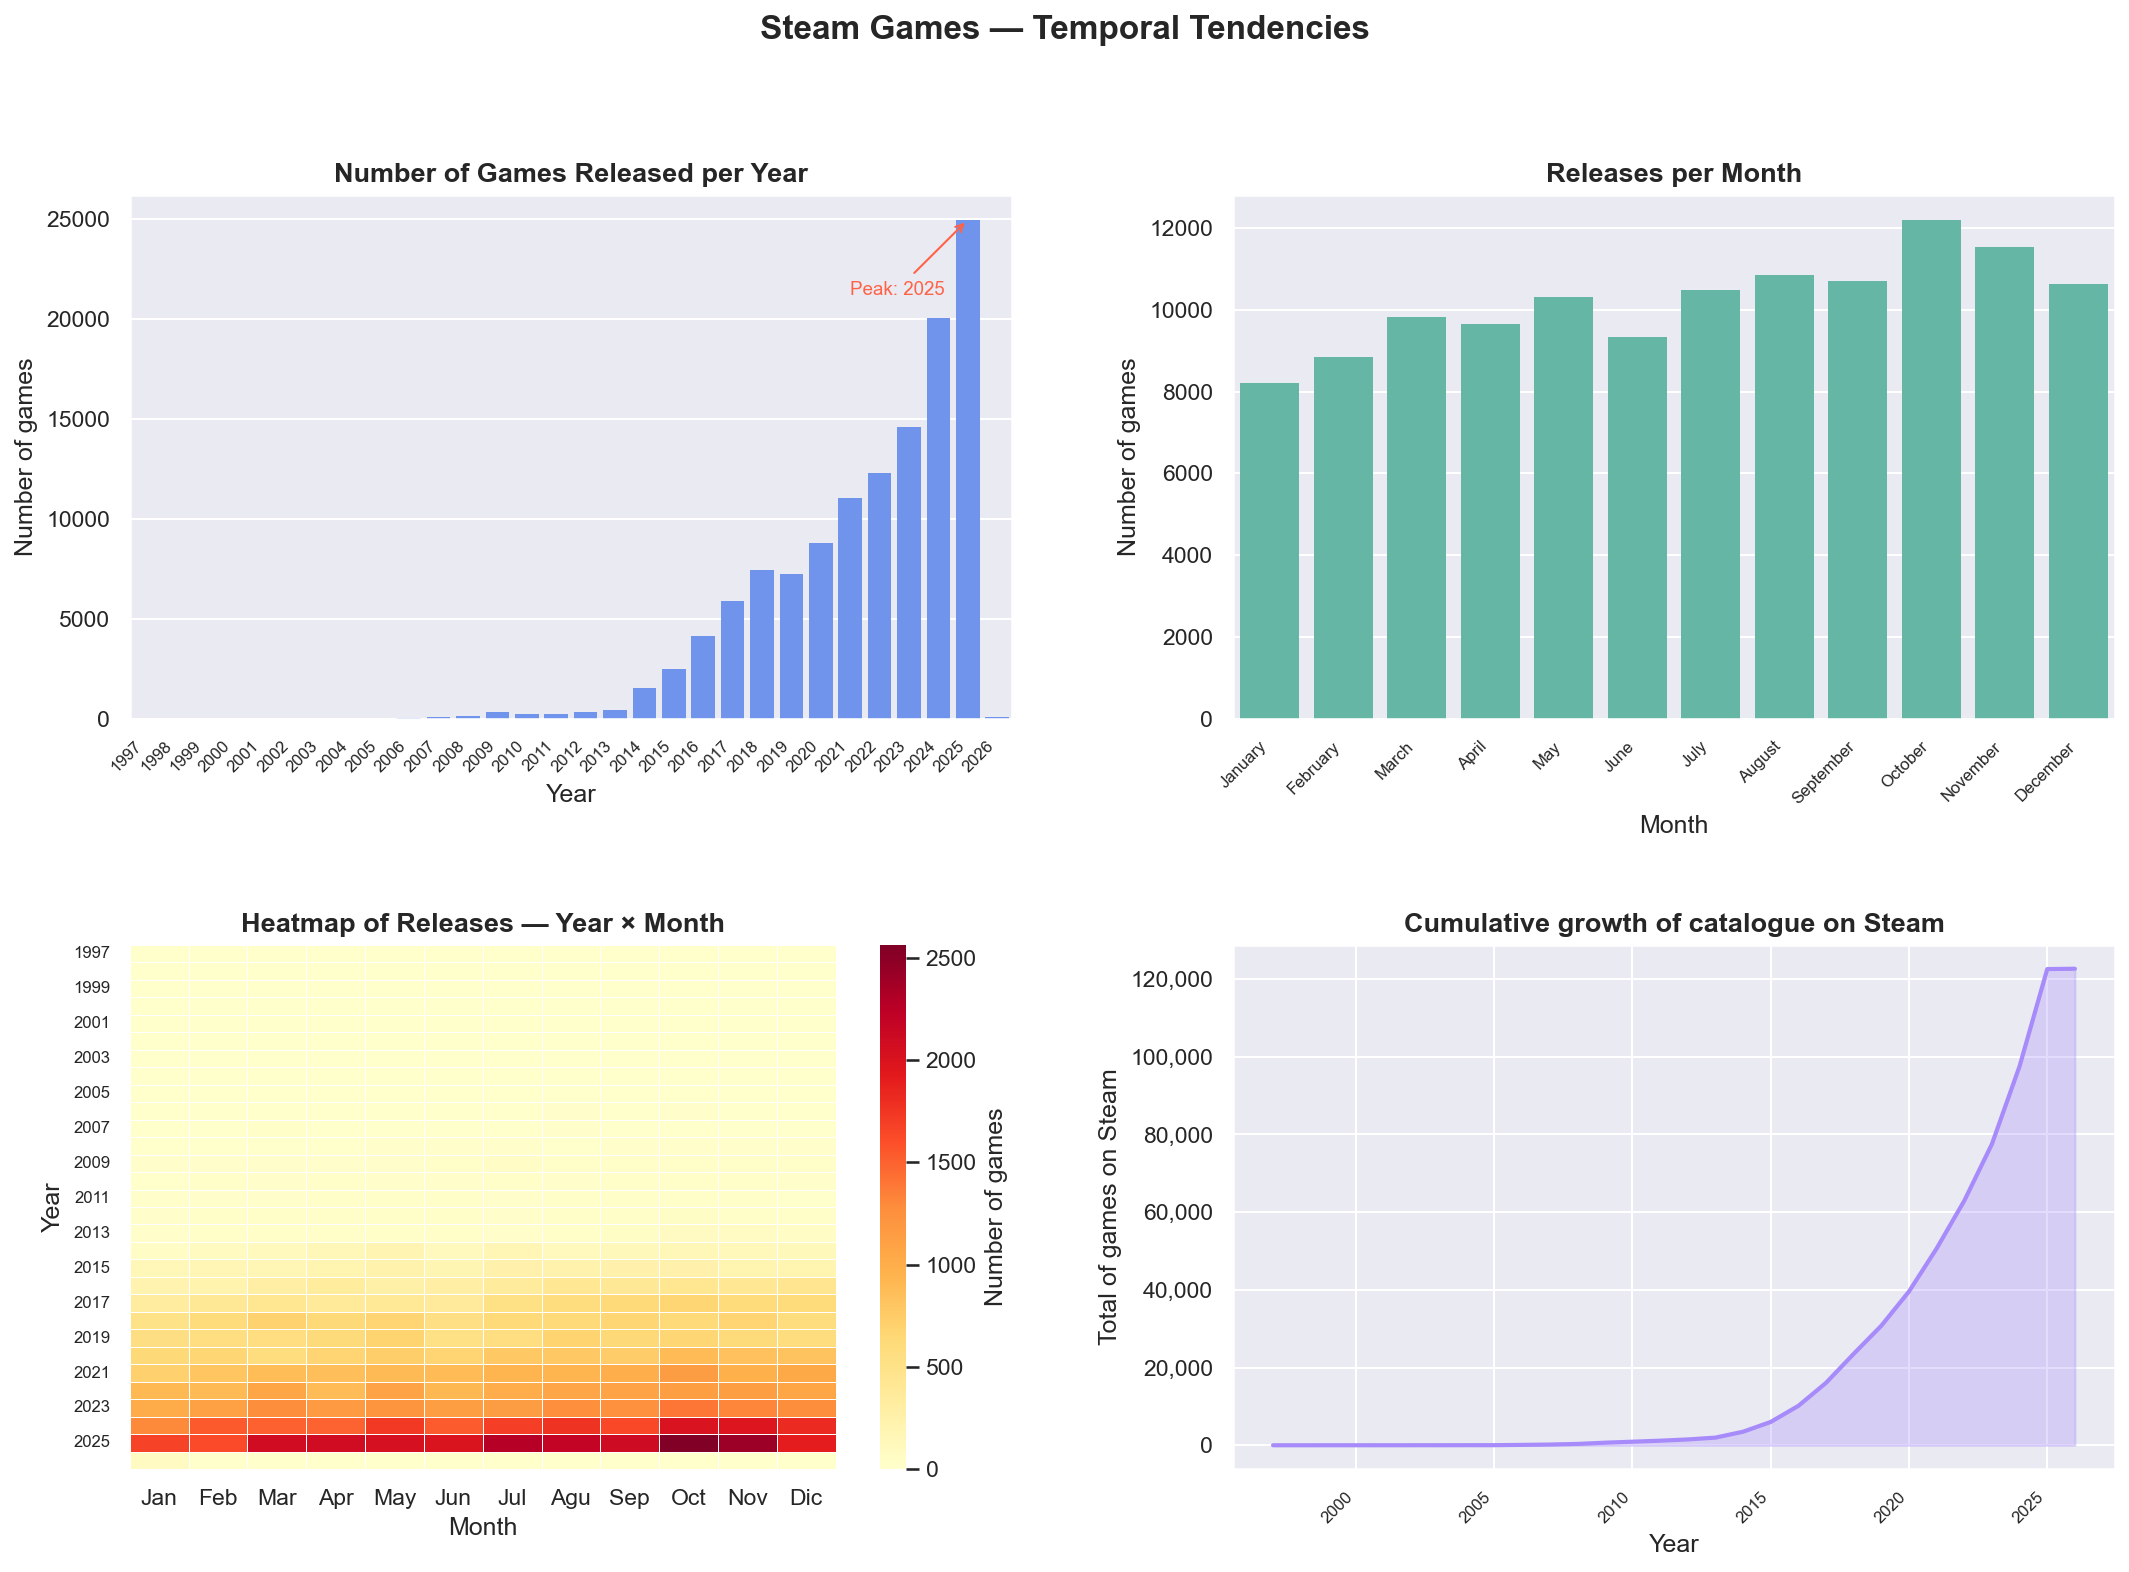

In [17]:
# Tendencies 
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    "Steam Games — Temporal Tendencies",
    fontsize=16,
    fontweight="bold"
)

#Filter valid years and discard nulls, future and very old years(unc years)
games_time = games[(games['release_year']) >= 2000 & (games['release_year'] <= 2026)].copy()


# =============================================================================
# Releases per year
# =============================================================================

ax1 = axes[0, 0]

releases_per_year = games_time.groupby('release_year').size().reset_index(name='count')

sns.barplot(
    data=releases_per_year,
    x='release_year',
    y='count',
    ax=ax1,
    color="#5B8CFF",
    edgecolor="none"
)

ax1.set_title("Number of Games Released per Year")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of games")

# Rotate labels to not overtop
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)

# Max peak
peak_year = releases_per_year.loc[releases_per_year['count'].idxmax()]
ax1.annotate(
    f"Peak: {int(peak_year['release_year'])}",
    xy=(releases_per_year.index[releases_per_year['release_year'] == peak_year['release_year']][0],
        peak_year['count']),
    xytext=(releases_per_year.index[releases_per_year['release_year'] == peak_year['release_year']][0] - 4,
            peak_year['count'] * 0.85),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# =============================================================================
# PLOT 2 — Releases per month 
# =============================================================================

ax2 = axes[0, 1]

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

releases_per_month = (
    games_time.groupby('month_name')
    .size()
    .reindex(month_order)
    .reset_index(name='count')
)

sns.barplot(
    data=releases_per_month,
    x='month_name',
    y='count',
    ax=ax2,
    color="#57C4AD",
    edgecolor="none"
)

ax2.set_title("Releases per Month")
ax2.set_xlabel("Month")
ax2.set_ylabel("Number of games")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)


# =============================================================================
# PLOT 3 — Heatmap year x month
# =============================================================================

ax3 = axes[1, 0]

# Pivot: rows = year, columns = months
heatmap_data = (
    games_time.groupby(['release_year', 'release_month'])
    .size()
    .unstack(fill_value=0)
)

# Rename columns to month names 
month_abbr = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Agu','Sep','Oct','Nov','Dic']
heatmap_data.columns = month_abbr

sns.heatmap(
    heatmap_data,
    ax=ax3,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Number of games'}
)

ax3.set_title("Heatmap of Releases — Year × Month")
ax3.set_xlabel("Month")
ax3.set_ylabel("Year")
ax3.tick_params(axis='y', labelsize=8)

# =============================================================================
# PLOT 4 — Cumulative growth of games on Steam 
# =============================================================================

ax4 = axes[1, 1]

cumulative = releases_per_year.copy()
cumulative['cumulative'] = cumulative['count'].cumsum()

ax4.fill_between(
    cumulative['release_year'],
    cumulative['cumulative'],
    alpha=0.3,
    color="#A78BFA"
)

ax4.plot(
    cumulative['release_year'],
    cumulative['cumulative'],
    color="#A78BFA",
    linewidth=2
)

ax4.set_title("Cumulative growth of catalogue on Steam")
ax4.set_xlabel("Year")
ax4.set_ylabel("Total of games on Steam")

# Format Y with delimiter of thousands
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=8)

# =============================================================================
# FINAL AJUSTSMENTS 
# =============================================================================

plt.tight_layout(pad=3)
plt.savefig('../images/02_temp_tendencies.png', bbox_inches='tight', dpi=150)
plt.show()  #LOTS OF USERWARNINGS CAUSE OF TICKETLABLES, STILL NEED TO VERTIFIY LOST OF THINGS
